# <center> Elementy numerycznej algebry liniowej </center>

Rozwiązywanie układów równań liniowych jest jednym z podstawowych problemów metod numerycznych. Układy równań liniowych występują w wielu dziedzinach nauki i inżynierii. Stosuje się też w uczeniu maszynowym np. podczas regresji z błędem średniokwadratowym. 


Istnieje kilka metod rozwiązywania układów równań. Na dzisiejszych zajęciach zajmiemy się:
* eliminacją Gaussa bez oraz z wyborem elementu głównego,
* metodami iteracyjnymi.

Problem rozwiązywania układu równań liniowych będzie nam towarzyszły do końca zajęć z tego przedmiotu.

## Normy i wskaźniki uwarunkowania

Wrażliwość układu (zmiana rozwiązania) na niewielkie zaburzenia wektora `b` zależy od macierzy `A` i ocenia się ja za pomocą tzw. współczynnika lub [wskaźnika uwarunkowania macierzy](https://pl.wikipedia.org/wiki/Wskaźnik_uwarunkowania) (ang. *condition number*). Im wyższa wartość tego wskaźnika. tym macierz jest gorzej uwarunkowana. Wskaźnik uwarunkowania to iloczyn normy macierzy z normą jej odwrotności.

$$cond(A)=|A|_{p}\cdot|A^{-1}|_{p}$$
gdzie *p* oznacza jedną z norm macierzy.

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

***Zadanie 1.***

Porównaj normy 1,2, $\infty$ następujących macierzy:
* [Hilberta](https://pl.wikipedia.org/wiki/Macierz_Hilberta): o wymiarach 5x5 i 15x15
* [Vandermonde'a](https://pl.wikipedia.org/wiki/Macierz_Vandermonde’a): o wymiarach 5x5 i 15x15
* losowej o wartościach z przedziału [0,1]:  o wymiarach 5x5 i 15x15
* $P=\left[\begin{array}{cccc}4 & 1 & -1 & 0 \\ 1 & 3 & -1 & 0 \\ -1 & -1 & 5 & 2 \\ 0 & 0 & 2 & 4\end{array}\right]$

Czy wśród powyższych macierzy jest macierz [diagonalnie dominująca](https://pl.wikipedia.org/wiki/Macierz_przekątniowo_dominująca)?


In [3]:
import numpy as np
from scipy.linalg import hilbert

def oblicz_normy(A):
    return np.linalg.norm(A, 1), np.linalg.norm(A, 2), np.linalg.norm(A, np.inf)

def czy_diagonalnie_dominujaca(A):
    abs_diag = np.abs(np.diag(A))
    row_sum = np.sum(np.abs(A), axis=1) - abs_diag
    return np.all(abs_diag >= row_sum)

P = np.array([
    [4, 1, -1, 0],
    [1, 3, -1, 0],
    [-1, -1, 5, 2],
    [0, 0, 2, 4]
])

n1, n2, ninf = oblicz_normy(P)
dominacja = czy_diagonalnie_dominujaca(P)

print(f"Macierz P:\nNorma 1: {n1}\nNorma 2: {n2:.4f}\nNorma inf: {ninf}")
print(f"Czy diagonalnie dominująca? {dominacja}")

Macierz P:
Norma 1: 9.0
Norma 2: 7.0861
Norma inf: 9.0
Czy diagonalnie dominująca? True


*Wskazówka: Do wyznaczenia norm możesz wykorzystać funkcję `numpy.linalg.norm`*

***Zadanie 2.***

Oblicz wskaźniki uwarunkowania macierzy z poprzedniego zadania.

*Wskazówka: Możesz wykorzystać funkcję `numpy.linalg.cond`.*

In [4]:
import numpy as np
import pandas as pd
from scipy.linalg import hilbert

def czy_diagonalnie_dominujaca(A):
    abs_diag = np.abs(np.diag(A))
    row_sum = np.sum(np.abs(A), axis=1) - abs_diag
    return "Tak" if np.all(abs_diag >= row_sum) else "Nie"

macierze = []

macierze.append(("Hilbert", 5, hilbert(5)))
macierze.append(("Hilbert", 15, hilbert(15)))

macierze.append(("Vandermonde", 5, np.vander(np.arange(1, 6))))
macierze.append(("Vandermonde", 15, np.vander(np.arange(1, 16))))

np.random.seed(42) 
macierze.append(("Losowa", 5, np.random.rand(5, 5)))
macierze.append(("Losowa", 15, np.random.rand(15, 15)))

P = np.array([
    [4, 1, -1, 0],
    [1, 3, -1, 0],
    [-1, -1, 5, 2],
    [0, 0, 2, 4]
])
macierze.append(("Macierz P", 4, P))

wyniki = []

for nazwa, rozmiar, M in macierze:
    n1 = np.linalg.norm(M, 1)
    n2 = np.linalg.norm(M, 2)
    ninf = np.linalg.norm(M, np.inf)
    
    c1 = np.linalg.cond(M, 1)
    c2 = np.linalg.cond(M, 2)
    cinf = np.linalg.cond(M, np.inf)
    
    dom = czy_diagonalnie_dominujaca(M)
    
    wyniki.append({
        "Typ": nazwa,
        "Wymiar": f"{rozmiar}x{rozmiar}",
        "Norma 1": n1,
        "Norma 2": n2,
        "Norma Inf": ninf,
        "Cond(2)": c2,
        "Diag. Dom.": dom
    })

df = pd.DataFrame(wyniki)
pd.options.display.float_format = '{:.2e}'.format 

print("=== WYNIKI ANALIZY MACIERZY ===")
print(df.to_string(index=False))

print("\n--- Szczegóły dla Macierzy P ---")
print(f"Wskaźnik uwarunkowania cond(2): {np.linalg.cond(P, 2):.4f}")
print(f"Czy diagonalnie dominująca? {czy_diagonalnie_dominujaca(P)}")

=== WYNIKI ANALIZY MACIERZY ===
        Typ Wymiar  Norma 1  Norma 2  Norma Inf  Cond(2) Diag. Dom.
    Hilbert    5x5 2.28e+00 1.57e+00   2.28e+00 4.77e+05        Nie
    Hilbert  15x15 3.32e+00 1.85e+00   3.32e+00 3.68e+17        Nie
Vandermonde    5x5 9.79e+02 6.96e+02   7.81e+02 2.62e+04        Nie
Vandermonde  15x15 4.60e+16 3.16e+16   3.13e+16 2.58e+21        Nie
     Losowa    5x5 3.25e+00 2.35e+00   2.81e+00 6.55e+03        Nie
     Losowa  15x15 9.54e+00 7.59e+00   9.18e+00 8.54e+01        Nie
  Macierz P    4x4 9.00e+00 7.09e+00   9.00e+00 3.54e+00        Tak

--- Szczegóły dla Macierzy P ---
Wskaźnik uwarunkowania cond(2): 3.5431
Czy diagonalnie dominująca? Tak


## Rozwiązywanie układów równań metodą eliminacji Gaussa

***Zadanie 3.***

Jedną z metod rozwiązywania układów równań liniowych jest metoda eliminacji Gaussa. Metoda ta występuje w kilku odmianach. Poza podstawowym wariantem, możliwe jest zastosowanie metody z wyborem elementu głownego (tzw. *pivoting*). 

Celem tego zadania jest porównanie błędów rozwiązania otrzymanego z tych dwóch wariantów eliminacji Gaussa. Poniżej znajdują się implementacje obu tych metod. Każda z funkcji przyjmuje macierz `A` oraz wektor prawej strony równania `b`.

Samo polecenie znajduje się poniżej.

In [ ]:
def gauss_pivot(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        ind_max = k
        for j in range(k+1, n):
            if abs(A[j,k]) > abs(A[ind_max,k]):
                ind_max = j
        if ind_max > k:
            tmp = A[ind_max,k:n].copy()
            A[ind_max,k:n] = A[k,k:n]
            A[k,k:n] = tmp
            tmp = b[ind_max].copy()
            b[ind_max] = b[k]
            b[k] = tmp
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1]/A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

In [ ]:
def gauss(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

Stwórz macierze wartości losowych `A` o wymiarach 10x10 oraz wektor `b` o odpowiednich wymiarach. 
Chcemy rozwiązać układ równań `Ax=b` metodami eliminacji Gaussa bez oraz z wyborem elementu głównego, a następnie porównać dokładność wyników. Metoda z wyborem elementu głównego powinna dawać mniejszy błąd w przypadku dużych wartości znajdujących się na przekątnej. Sprawdź czy to prawda powtarzając obliczenia z  macierzami `A` zawierającym na pierwszym elemencie przekątnej coraz to mniejsze wartości (tak aby wzrosło znaczenie dalszych elementów na przękątnej i tym samym uaktywnił się wybór innego niż pierwszy elementu głównego).

Wskazówka:Do porównania możesz wykorzystać residuum. Jeżeli `x` jest rozwiązaniem układu to `Ax` powinno być równe `b`. Residuum to różnica pomiędzy `b` oraz `Ax`: `res=|b-Ax|`. Możesz porównać zawartości poszczególnych elementów lub obliczyć jakąś normę z otrzymanego wektora.

In [5]:
import numpy as np

def gauss_pivot(A, b):
    A = A.copy().astype(float)
    b = b.copy().astype(float)
    n = len(b)
    for k in range(n-1):
        ind_max = k
        for j in range(k+1, n):
            if abs(A[j, k]) > abs(A[ind_max, k]):
                ind_max = j
        if ind_max > k:
            A[[k, ind_max]] = A[[ind_max, k]]
            b[k], b[ind_max] = b[ind_max], b[k]
        
        akk = A[k, k]
        l = A[k+1:n, k] / akk
        for i in range(k+1, n):
            A[i, k] = 0
            A[i, k+1:n] = A[i, k+1:n] - l[i-k-1] * A[k, k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
            
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1, n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k, k+1:n], x[k+1:n])) / A[k, k]
    return x

def gauss(A, b):
    A = A.copy().astype(float)
    b = b.copy().astype(float)
    n = len(b)
    for k in range(n-1):
        akk = A[k, k]
        l = A[k+1:n, k] / akk
        for i in range(k+1, n):
            A[i, k] = 0
            A[i, k+1:n] = A[i, k+1:n] - l[i-k-1] * A[k, k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
            
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1, n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k, k+1:n], x[k+1:n])) / A[k, k]
    return x

np.random.seed(10) 
A_orig = np.random.rand(10, 10)
b_orig = np.random.rand(10)

wartosci_a00 = [1.0, 1e-5, 1e-10, 1e-15, 1e-18]

print(f"{'A[0,0]':<10} | {'Błąd Gauss':<15} | {'Błąd Gauss Pivot':<15}")
print("-" * 45)

for val in wartosci_a00:
    A = A_orig.copy()
    A[0, 0] = val  
    
    try:
        x_g = gauss(A, b_orig)
        x_p = gauss_pivot(A, b_orig)
        
        res_g = np.linalg.norm(b_orig - np.dot(A, x_g))
        res_p = np.linalg.norm(b_orig - np.dot(A, x_p))
        
        print(f"{val:<10.0e} | {res_g:<15.2e} | {res_p:<15.2e}")
    except ZeroDivisionError:
        print(f"{val:<10.0e} | Błąd (dzielenie przez 0) | {res_p:<15.2e}")

A[0,0]     | Błąd Gauss      | Błąd Gauss Pivot
---------------------------------------------
1e+00      | 4.48e-15        | 1.51e-15       
1e-05      | 1.13e-11        | 8.03e-16       
1e-10      | 6.50e-06        | 1.13e-15       
1e-15      | 2.41e-01        | 8.46e-16       
1e-18      | nan             | 7.04e-16       


C:\Users\kacpe\AppData\Local\Temp\ipykernel_27928\1091051213.py:35: RuntimeWarning: divide by zero encountered in divide
  l = A[k+1:n, k] / akk
C:\Users\kacpe\AppData\Local\Temp\ipykernel_27928\1091051213.py:35: RuntimeWarning: invalid value encountered in divide
  l = A[k+1:n, k] / akk
C:\Users\kacpe\AppData\Local\Temp\ipykernel_27928\1091051213.py:38: RuntimeWarning: invalid value encountered in multiply
  A[i, k+1:n] = A[i, k+1:n] - l[i-k-1] * A[k, k+1:n]


## Metody iteracyjne

Innym sposobem na rozwiązanie układu równań liniowych jest wykorzystanie metod iteracyjnych, które generują ciągi przybliżeń wektora stanowiącego rozwiązanie układu. Państwa zadaniem będzie implementacja i porównanie zbieżności trzech najpopularniejszych metod iteracyjnego rozwiązywania układów równań liniowych

***Zadanie 4.***

Porównanie zbieżności metod Jacobiego, Gaussa-Seidla i Younga (SOR).
* Zaimplementuj solvery rozwiązujące układy równań metodami Jacobiego, Gaussa-Seidela  i Younga (SOR). Każda funkcja powinna przyjmować macierz A i wektor prawej strony b. Dla uproszczenia, dopuszczalne jest wykorzystanie  inv dla obliczenia macierzy odwrotnej do macierzy trójkątnej (w metodzie G-S i Younga).
* Porównaj zbieżność ciągów iteracyjnych otrzymanych 3 metodami dla 3 układów równań (3 macierzy). W metodzie Younga możesz przyjąć np. $ω = 1.2$.
* Dla macierzy, dla której metoda Younga okazała się zbieżna, porównaj zbieżność ciągów iteracyjnych otrzymanych dla wartości $0 < ω < 3$ (dodatkowe).
* Dla jakiej wartości parametru $ω$ zbieżność ciągu iteracyjnego jest najlepsza? Wynik otrzymany na podstawie obserwacji ciągu odchyleń od rozwiązania dokładnego należy porównać z wnioskiem płynącym z wykresu zależności promienia spektralnego macierzy iteracji w zależności od parametru $ω$ (dodatkowe).

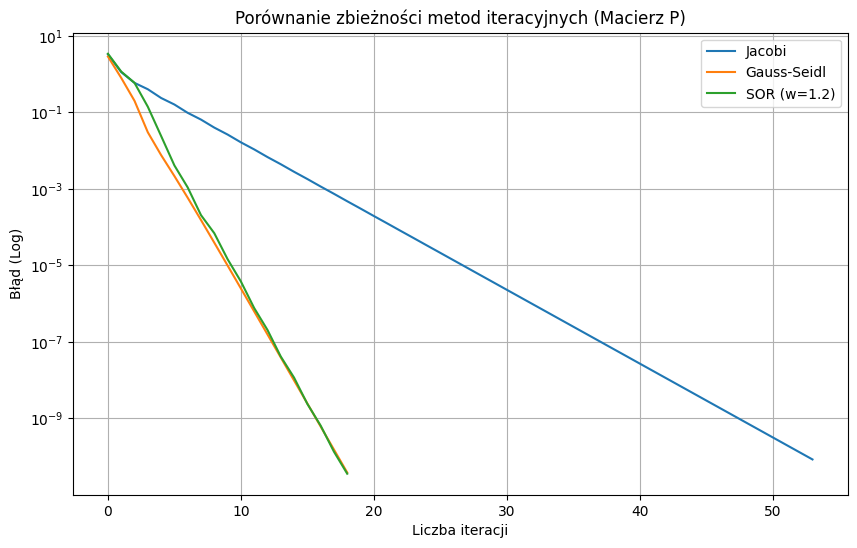

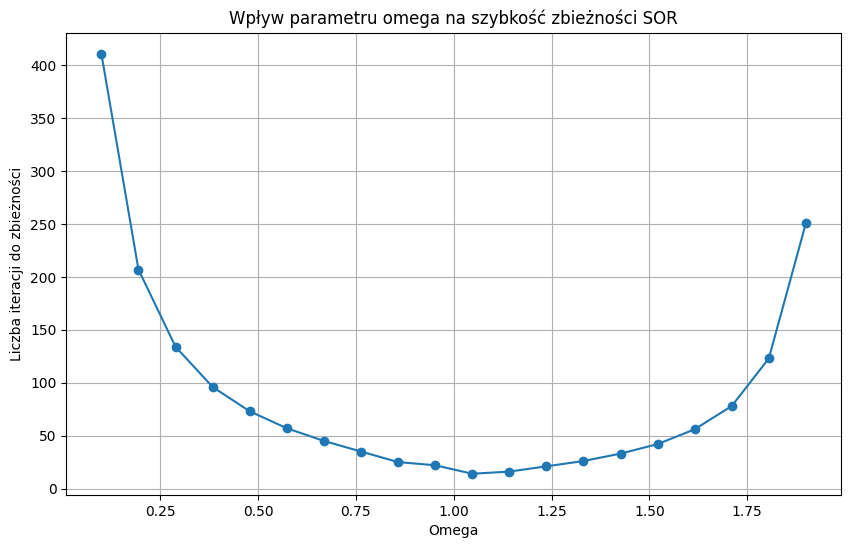

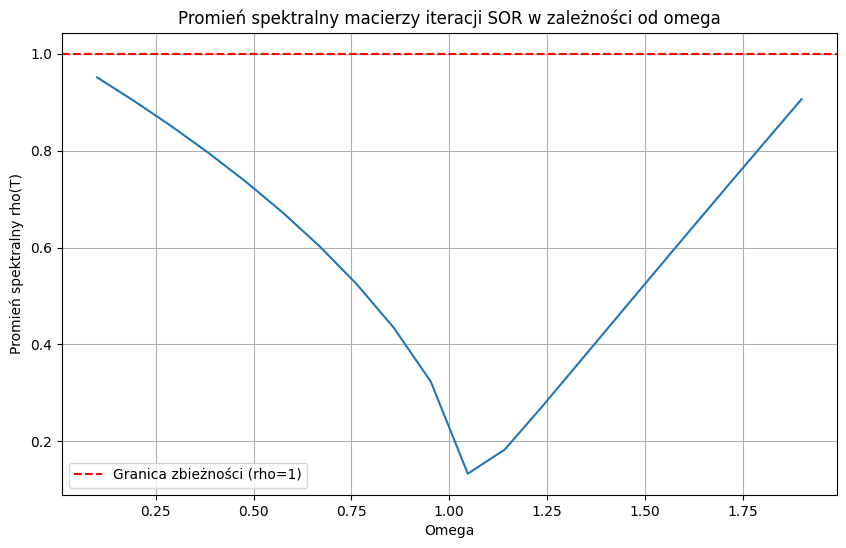

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol=1e-10, max_iter=500):
    D = np.diag(np.diag(A))
    LU = A - D
    x = x0.copy()
    errors = []
    for _ in range(max_iter):
        x_new = np.linalg.inv(D) @ (b - LU @ x)
        err = np.linalg.norm(x_new - x)
        errors.append(err)
        if err < tol: break
        x = x_new
    return x, errors

def gauss_seidl(A, b, x0, tol=1e-10, max_iter=500):
    LD = np.tril(A)
    U = A - LD
    x = x0.copy()
    errors = []
    inv_LD = np.linalg.inv(LD)
    for _ in range(max_iter):
        x_new = inv_LD @ (b - U @ x)
        err = np.linalg.norm(x_new - x)
        errors.append(err)
        if err < tol: break
        x = x_new
    return x, errors

def sor(A, b, x0, omega, tol=1e-10, max_iter=500):
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)
    M = D + omega * L
    N = (1 - omega) * D - omega * U
    x = x0.copy()
    errors = []
    inv_M = np.linalg.inv(M)
    for _ in range(max_iter):
        x_new = inv_M @ (N @ x + omega * b)
        err = np.linalg.norm(x_new - x)
        errors.append(err)
        if err < tol: break
        x = x_new
    return x, errors

P = np.array([[4, 1, -1, 0], [1, 3, -1, 0], [-1, -1, 5, 2], [0, 0, 2, 4]])
b_P = np.array([5, 3, 10, 8])


np.random.seed(42)
R = np.random.rand(4, 4) + np.eye(4) * 2
b_R = np.random.rand(4)

from scipy.linalg import hilbert
H = hilbert(4)
b_H = np.ones(4)

x0 = np.zeros(4)

_, err_j = jacobi(P, b_P, x0)
_, err_gs = gauss_seidl(P, b_P, x0)
_, err_sor = sor(P, b_P, x0, omega=1.2)

plt.figure(figsize=(10, 6))
plt.semilogy(err_j, label='Jacobi')
plt.semilogy(err_gs, label='Gauss-Seidl')
plt.semilogy(err_sor, label='SOR (w=1.2)')
plt.title('Porównanie zbieżności metod iteracyjnych (Macierz P)')
plt.xlabel('Liczba iteracji')
plt.ylabel('Błąd (Log)')
plt.legend()
plt.grid(True)
plt.show()

omegas = np.linspace(0.1, 1.9, 20)
iter_counts = []

for o in omegas:
    _, errs = sor(P, b_P, x0, omega=o)
    iter_counts.append(len(errs))

plt.figure(figsize=(10, 6))
plt.plot(omegas, iter_counts, 'o-')
plt.title('Wpływ parametru omega na szybkość zbieżności SOR')
plt.xlabel('Omega')
plt.ylabel('Liczba iteracji do zbieżności')
plt.grid(True)
plt.show()

def get_spectral_radius(A, omega):
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)
    T = np.linalg.inv(D + omega * L) @ ((1 - omega) * D - omega * U)
    return max(abs(np.linalg.eigvals(T)))

rho_values = [get_spectral_radius(P, o) for o in omegas]

plt.figure(figsize=(10, 6))
plt.plot(omegas, rho_values)
plt.axhline(y=1, color='r', linestyle='--', label='Granica zbieżności (rho=1)')
plt.title('Promień spektralny macierzy iteracji SOR w zależności od omega')
plt.xlabel('Omega')
plt.ylabel('Promień spektralny rho(T)')
plt.legend()
plt.grid(True)
plt.show()

## Porównanie rozwiązania za pomocą metody `solve` oraz z użyciem odwrotności na przykładzie macierzy źle uwarunkowanej

***Zadanie 5.***

Dany jest układ równań $Hx=b$.
* H jest macierzą Hilberta o wymiarach $n=5x5$ (I przypadek) i $n=15x15$ (II przypadek),
* b jest wektorem o następujących elementach $b_i = 1/(n + i + 1)$ Uwaga: $i=1,\dots,n$.

Do rozwiązania układu wykorzystaj dwa algorytmy:
1. Z odwracaniem macierzy współczynników H.
2. Metodę `numpy.linalg.solve`.

Porównaj błędy obu rozwiązań. Aby ocenić błąd możesz:
* wyznaczyć wektor residuum otrzymanego rozwiązania,
* rozwiązać układ równań z innym wektorem $b$. Załóż, że wektor rozwiązania ma wszystkie elementy (współrzędne) równe 1 ($u_i = 1, i = 1, 2, . . . , n$). Wtedy $b = Hu$. Układ rozwiążemy bez korzystania z wiedzy o postaci $u$. Dopiero wynik porównamy ze znanym nam $u$.

In [7]:
import numpy as np
from scipy.linalg import hilbert

def rozwiaz_i_porownaj(n):
    H = hilbert(n)
    
    b = np.array([1.0 / (n + (i + 1) + 1) for i in range(n)])
    
    try:
        H_inv = np.linalg.inv(H)
        x_inv = H_inv @ b
    except np.linalg.LinAlgError:
        x_inv = np.zeros(n)
        print(f"Błąd: Macierz H {n}x{n} jest osobliwa dla np.linalg.inv")

    x_solve = np.linalg.solve(H, b)
    
    res_inv = np.linalg.norm(b - H @ x_inv)
    res_solve = np.linalg.norm(b - H @ x_solve)
    
    u_known = np.ones(n)
    b_test = H @ u_known
    
    x_test_inv = np.linalg.inv(H) @ b_test
    x_test_solve = np.linalg.solve(H, b_test)
    
    err_u_inv = np.linalg.norm(u_known - x_test_inv)
    err_u_solve = np.linalg.norm(u_known - x_test_solve)
    
    print(f"\n--- WYNIKI DLA n = {n} ---")
    print(f"{'Metoda':<20} | {'Residuum (b-Hx)':<15} | {'Błąd (u-x_test)':<15}")
    print("-" * 60)
    print(f"{'H_inv @ b':<20} | {res_inv:<15.2e} | {err_u_inv:<15.2e}")
    print(f"{'np.linalg.solve':<20} | {res_solve:<15.2e} | {err_u_solve:<15.2e}")
    print(f"Wskaźnik uwarunkowania cond(H): {np.linalg.cond(H):.2e}")

rozwiaz_i_porownaj(5)
rozwiaz_i_porownaj(15)


--- WYNIKI DLA n = 5 ---
Metoda               | Residuum (b-Hx) | Błąd (u-x_test)
------------------------------------------------------------
H_inv @ b            | 1.18e-12        | 9.16e-11       
np.linalg.solve      | 1.67e-16        | 3.76e-12       
Wskaźnik uwarunkowania cond(H): 4.77e+05

--- WYNIKI DLA n = 15 ---
Metoda               | Residuum (b-Hx) | Błąd (u-x_test)
------------------------------------------------------------
H_inv @ b            | 9.37e-02        | 1.74e+03       
np.linalg.solve      | 2.00e-15        | 1.91e+01       
Wskaźnik uwarunkowania cond(H): 3.68e+17


**Zadanie domowe. Znaczenie wskaźnika uwarunkowania macierzy w szacowaniu błędu rozwiązania**


Dana jest następująca macierz A współczynników układu dwóch równań liniowy:
$$A=\begin{bmatrix}10^5 & 9.9\cdot10^4\\1.00001& 0.99\end{bmatrix}$$

Wektor prawej strony równania $Ax=b$ dla rozwiązania x = $[1, 1]^T$ możemy wyznaczyć z równości $b = Ax$.

Należy:
* obliczyć wskaźnik uwarunkowania macierzy $A$,
* rozwiązać układ równań $Ax = b$ (nie korzystając z wiedzy o przyjętym rozwiązaniu dokładnym x) korzystając z funkcji `np.linalg.solve`,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania macierzy A,
* przeprowadzić skalowanie tak, aby macierz $A$ była wyważona wierszami,
* wyznaczyć nowe wartości wektora b tak, aby rozwiązanie dokładne się nie
zmieniło,
* obliczyć wskaźnik uwarunkowania macierzy skalowanej,
* rozwiązać układ równań tą samą metodą jak poprzednio,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania skalowanej macierzy $A$.
1. Czy błąd numeryczny rozwiązania w obu przypadkach jest tego samego rzędu?
2. Które szacowanie błędu jest bardziej zbliżone do faktycznego błędu?